In [1]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input, Concatenate
from tensorflow.keras.models import Model
import pandas as pd
import numpy as np
import os
import glob
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


2025-09-17 14:46:42.194409: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-17 14:46:42.204571: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758113202.216318 2234879 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758113202.219753 2234879 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-17 14:46:42.232143: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:

# ----------------------------
# Config
# ----------------------------
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 50
LR = 1e-3
DROPOUT_RATE = 0.5
N_CLASSES = 3   # Normal, Benign, Malignant


In [3]:

# ----------------------------
# Load & Merge Metadata
# ----------------------------
excel_path = "CDD-CESM/Radiology-manual-annotations.xlsx"
sheets = pd.read_excel(excel_path, sheet_name=None)

df_merged = None
for name, sheet in sheets.items():
    if "Image_name" not in sheet.columns:
        continue
    if df_merged is None:
        df_merged = sheet
    else:
        df_merged = pd.merge(df_merged, sheet, on="Image_name", how="outer", suffixes=("", f"_{name}"))
        for col in df_merged.columns:
            if col.endswith(f"_{name}"):
                base_col = col.replace(f"_{name}", "")
                if base_col in df_merged.columns:
                    df_merged.drop(columns=[col], inplace=True)


In [4]:

# ----------------------------
# Load images & basic labels
# ----------------------------
image_root = "CDD-CESM/organized_images"
labels = ["benign", "malignant", "normal"]

rows = []
for label in labels:
    folder = os.path.join(image_root, label)
    for img_path in glob.glob(os.path.join(folder, "*")):
        img_name = os.path.basename(img_path)
        rows.append({
            "Image_name": img_name,
            "label": label.capitalize(),  # "Benign", "Malignant", "Normal"
            "filepath": img_path
        })

df_images = pd.DataFrame(rows)

# Merge metadata with images if needed
df = pd.merge(df_images, df_merged, on="Image_name", how="left")


In [5]:

# ----------------------------
# Tabular features
# ----------------------------
exclude_cols = ["Image_name", "filepath", "Diagnosis", "label"]
feature_cols = [c for c in df.columns if c not in exclude_cols]

X_tab = df[feature_cols].copy()
for col in X_tab.select_dtypes(include=["object"]).columns:
    X_tab[col] = X_tab[col].astype(str).fillna("NA")
    le = LabelEncoder()
    X_tab[col] = le.fit_transform(X_tab[col])
X_tab = X_tab.fillna(0)
scaler = StandardScaler()
X_tab = scaler.fit_transform(X_tab)


In [6]:

# ----------------------------
# Labels
# ----------------------------
if "Diagnosis" in df.columns:
    y = df["Diagnosis"].astype(str).str.capitalize()
else:
    y = df["label"].astype(str).str.capitalize()

label_map = {"Normal":0, "Benign":1, "Malignant":2}
y_numeric = y.map(label_map).values
y_onehot = tf.keras.utils.to_categorical(y_numeric, num_classes=N_CLASSES)



In [7]:

# ----------------------------
# Train/Validation Split
# ----------------------------
df["tabular"] = list(X_tab)
df["label_onehot"] = list(y_onehot)

train_df, val_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=y_numeric
)


In [8]:

# ----------------------------
# TF Dataset
# ----------------------------
import cv2

def preprocess_image(img_path):
    img_path = img_path.numpy().decode("utf-8")
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img_blur = cv2.GaussianBlur(img, (7, 7), 0)
    _, mask = cv2.threshold(img_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((15,15), np.uint8))
    # Keep largest contour only
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest = max(contours, key=cv2.contourArea)
        mask = np.zeros_like(mask)
        cv2.drawContours(mask, [largest], -1, 255, -1)
    coords = cv2.findNonZero(mask)
    x, y, w, h = cv2.boundingRect(coords)
    cropped = img_blur[y:y+h, x:x+w]
    norm_img = cv2.normalize(cropped, None, 0, 255, cv2.NORM_MINMAX)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    norm_img = clahe.apply(norm_img)
    norm_img = cv2.resize(norm_img, IMG_SIZE)
    norm_img = cv2.cvtColor(norm_img, cv2.COLOR_GRAY2RGB)
    norm_img = norm_img / 255.0
    return norm_img

def load_image(path, tab, label, augment=False):
    # Use deterministic preprocessing instead of random augmentation
    img = tf.py_function(preprocess_image, [path], tf.float32)
    img.set_shape((*IMG_SIZE, 3))
    return {"raw_image": img, "tabular": tab}, label

def make_dataset(df, augment=False):
    filepaths = df["filepath"].values
    X_tab = np.stack(df["tabular"].values)
    y_labels = np.stack(df["label_onehot"].values)
    ds = tf.data.Dataset.from_tensor_slices((filepaths, X_tab, y_labels))
    ds = ds.map(lambda p, t, l: load_image(p, t, l, augment), num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.shuffle(len(df))
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_dataset = make_dataset(train_df, augment=True)
val_dataset = make_dataset(val_df, augment=False)

#Print dataset repartition
print("Train set class distribution:")
print(train_df['label'].value_counts())
print("\nValidation set class distribution:")
print(val_df['label'].value_counts())



Train set class distribution:
label
Normal       604
Malignant    528
Benign       468
Name: count, dtype: int64

Validation set class distribution:
label
Normal       151
Malignant    133
Benign       117
Name: count, dtype: int64


2025-09-17 14:46:44.724932: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


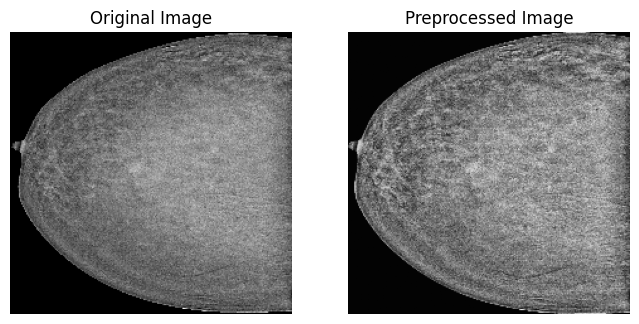

In [9]:
import matplotlib.pyplot as plt

# Pick a sample from the validation set
sample = val_df.sample(n=1).iloc[0]
img_path = sample["filepath"]
tab = sample["tabular"]
label = sample["label_onehot"]

# Load original image (before preprocessing)
orig_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
orig_img = cv2.resize(orig_img, IMG_SIZE)

# Load preprocessed image (after deterministic pipeline)
preprocessed, _ = load_image(img_path, tab, label, augment=False)
preprocessed_img = preprocessed["raw_image"].numpy()

# Plot both images
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(orig_img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(preprocessed_img)
plt.title("Preprocessed Image")
plt.axis("off")

plt.show()

In [10]:

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D

# Image branch (EfficientNetB0)
raw_in = Input(shape=(224, 224, 3), name="raw_image")
base_model = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=raw_in)
base_model.trainable = True  # Set to False for feature extraction, True for fine-tuning

c = base_model.output
c = GlobalAveragePooling2D()(c)
c = Dense(128, activation="relu")(c)
c = Dropout(0.5)(c)

# Tabular branch (unchanged)
tab_in = Input(shape=(X_tab.shape[1],), name="tabular")
t = Dense(128, activation="relu")(tab_in)
t = Dropout(0.3)(t)
t = Dense(64, activation="relu")(t)

# Fusion
fusion = Concatenate()([c, t])
fusion = Dense(128, activation="relu")(fusion)
fusion = Dropout(0.4)(fusion)
out = Dense(N_CLASSES, activation="softmax")(fusion)

model = Model(inputs=[raw_in, tab_in], outputs=out)

In [11]:

# ----------------------------
# Compile
# ----------------------------
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")]
)



In [12]:

# ----------------------------
# Callbacks
# ----------------------------
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.1, patience=5, verbose=1),
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
]


In [13]:

# ----------------------------
# Train
# ----------------------------
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_numeric),
    y=y_numeric
)
class_weight_dict = dict(enumerate(class_weights))

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight_dict  # Add this argument
)


Epoch 1/50


2025-09-17 14:47:23.084975: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 337 of 1600
2025-09-17 14:47:33.091838: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 745 of 1600
2025-09-17 14:47:53.044187: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1516 of 1600
2025-09-17 14:47:54.602937: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


100/100 ━━━━━━━━━━━━━━━━━━━━ 297s 2s/step - accuracy: 0.3503 - loss: 1.1239 - precision: 0.3888 - recall: 0.0449 - val_accuracy: 0.2918 - val_loss: 1.1031 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/50


2025-09-17 14:51:53.635214: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 233 of 1600
2025-09-17 14:52:14.024506: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 778 of 1600
2025-09-17 14:52:33.526607: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1290 of 1600
2025-09-17 14:52:43.735407: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1503 of 1600
2025-09-17 14:52:46.730874: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


100/100 ━━━━━━━━━━━━━━━━━━━━ 507s 4s/step - accuracy: 0.4403 - loss: 1.0620 - precision: 0.6467 - recall: 0.0679 - val_accuracy: 0.3042 - val_loss: 1.1075 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 3/50


...

100/100 ━━━━━━━━━━━━━━━━━━━━ 3296s 33s/step - accuracy: 0.8249 - loss: 0.4315 - precision: 0.8696 - recall: 0.7832 - val_accuracy: 0.6010 - val_loss: 0.9466 - val_precision: 0.6000 - val_recall: 0.5536 - learning_rate: 1.0000e-07
Epoch 30/50


2025-09-17 19:06:17.075888: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 654 of 1600
2025-09-17 19:06:30.975054: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


100/100 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - accuracy: 0.8224 - loss: 0.4640 - precision: 0.8549 - recall: 0.7625 - val_accuracy: 0.5935 - val_loss: 0.9445 - val_precision: 0.6049 - val_recall: 0.5536 - learning_rate: 1.0000e-07
Epoch 31/50


2025-09-17 19:09:14.608080: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 555 of 1600
2025-09-17 19:09:24.665875: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1110 of 1600
2025-09-17 19:09:33.240937: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8437 - loss: 0.4351 - precision: 0.8936 - recall: 0.8019
Epoch 31: ReduceLROnPlateau reducing learning rate to 1.0000000116860975e-08.
100/100 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.8435 - loss: 0.4353 - precision: 0.8934 - recall: 0.8017 - val_accuracy: 0.6010 - val_loss: 0.9467 - val_precision: 0.6027 - val_recall: 0.5486 - learning_rate: 1.0000e-07


In [14]:

# ----------------------------
# Evaluate
# ----------------------------
loss, acc, prec, rec = model.evaluate(val_dataset)
print(f"Validation Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}, Recall: {rec:.4f}")


26/26 ━━━━━━━━━━━━━━━━━━━━ 14s 505ms/step - accuracy: 0.5685 - loss: 0.9155 - precision: 0.6019 - recall: 0.5303
Validation Accuracy: 0.5736
Precision: 0.6017, Recall: 0.5312


2025-09-17 19:12:38.783614: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


26/26 ━━━━━━━━━━━━━━━━━━━━ 17s 548ms/step


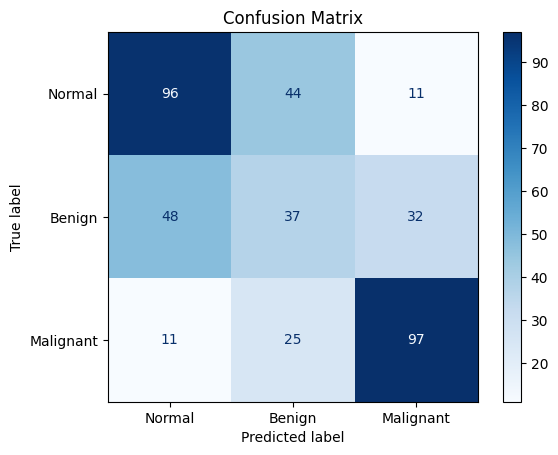

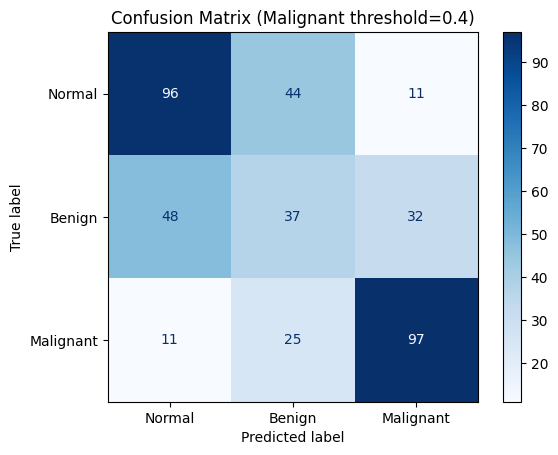

Default Malignant Recall: 0.7293
Thresholded Malignant Recall: 0.7293


In [15]:
# ----------------------------
# Confusion Matrix & Malignant Recall
# ----------------------------
y_true = np.concatenate([y for x, y in val_dataset], axis=0)
y_pred_probs = model.predict(val_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_true, axis=1)

# Standard confusion matrix
cm = confusion_matrix(y_true_classes, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Benign", "Malignant"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# Adjust threshold for malignant detection
malignant_threshold = 0.4
y_pred_malignant = np.where(y_pred_probs[:,2] > malignant_threshold, 2, y_pred)

# Confusion matrix with thresholded malignant detection
cm_thresh = confusion_matrix(y_true_classes, y_pred_malignant)
disp_thresh = ConfusionMatrixDisplay(cm_thresh, display_labels=["Normal", "Benign", "Malignant"])
disp_thresh.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix (Malignant threshold={malignant_threshold})")
plt.show()

# Malignant recall scores
from sklearn.metrics import recall_score
malignant_recall_default = recall_score(y_true_classes == 2, y_pred == 2)
malignant_recall_thresh = recall_score(y_true_classes == 2, y_pred_malignant == 2)
print(f"Default Malignant Recall: {malignant_recall_default:.4f}")
print(f"Thresholded Malignant Recall: {malignant_recall_thresh:.4f}")

2025-09-17 19:13:02.699111: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 526ms/step


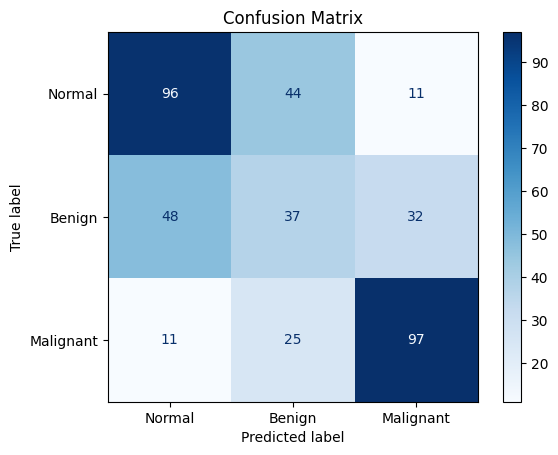

In [16]:

# ----------------------------
# Confusion Matrix
# ----------------------------
y_true = np.concatenate([y for x, y in val_dataset], axis=0)
y_pred_probs = model.predict(val_dataset)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_true, axis=1)
cm = confusion_matrix(y_true_classes, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Benign", "Malignant"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


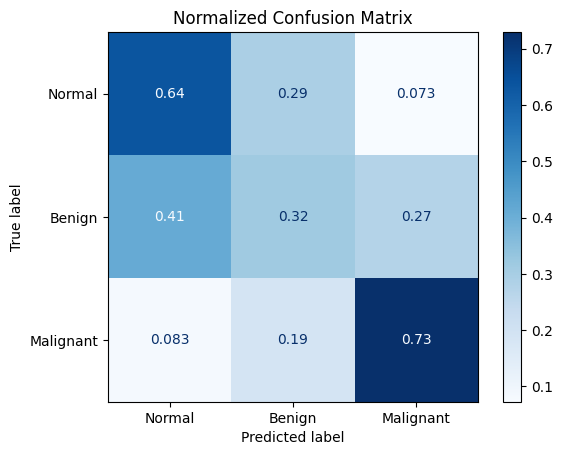

In [17]:
# filepath: /home/light/Documents/Perso/Internship/project/CDD_2_benchmark.ipynb
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(cm_norm, display_labels=["Normal", "Benign", "Malignant"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Normalized Confusion Matrix")
plt.show()

In [18]:
model.save("cdd_fusion_model_EfficientNetB0_3.h5")

In [19]:
def predict_class(image_path=None, tabular_array=None):
    # Prepare image
    if image_path is not None:
        img = tf.io.read_file(image_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img = img / 255.0
        img = tf.expand_dims(img, axis=0)  # Add batch dimension
    else:
        img = None

    # Prepare tabular data
    if tabular_array is not None:
        tab = np.array(tabular_array, dtype=np.float32)
        tab = np.expand_dims(tab, axis=0)  # Add batch dimension
    else:
        tab = None

    # Predict
    if img is not None and tab is not None:
        pred = model.predict({"raw_image": img, "tabular": tab})
    elif img is not None:
        pred = model.predict({"raw_image": img, "tabular": np.zeros((1, X_tab.shape[1]), dtype=np.float32)})
    elif tab is not None:
        pred = model.predict({"raw_image": np.zeros((1, *IMG_SIZE, 3), dtype=np.float32), "tabular": tab})
    else:
        raise ValueError("Provide at least image_path or tabular_array.")

    class_idx = np.argmax(pred, axis=1)[0]
    class_names = ["Normal", "Benign", "Malignant"]
    return class_names[class_idx], pred[0]

In [ ]:
# Get a random row from the xlsx and retrieve the corresponding tabular array for the image

import random

# Pick a random row from the validation dataframe
random_row = val_df.sample(n=1).iloc[0]

# Get the image path and tabular array
image_path = random_row["filepath"]
tabular_array = random_row["tabular"]

# Predict using both image and tabular data
result = predict_class(image_path=image_path, tabular_array=tabular_array)
print("Random image + tabular prediction:", result)
print("Image path:", image_path)
result_image_only = predict_class(image_path=image_path)
print("Image only prediction:", result_image_only)
result_tabular_only = predict_class(tabular_array=tabular_array)
print("Tabular only prediction:", result_tabular_only)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Random image + tabular prediction: ('Benign', array([0.19652061, 0.6692124 , 0.13426699], dtype=float32))
Image path: CDD-CESM/organized_images/normal/P101_L_DM_CC.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Image only prediction: ('Benign', array([0.19652061, 0.6692124 , 0.13426699], dtype=float32))
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Tabular only prediction: ('Benign', array([0.33529446, 0.35504285, 0.30966267], dtype=float32))


: 